In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import torch
from torch_geometric.data import Data
print(os.getpid())

2764811


In [80]:
folder_path = "Data"

sequence=[]
distance_map=[]
dca=[]
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence.append(loaded['sequence'])
        distance_map.append(loaded['distance_map'])
        dca.append(loaded['dca'])

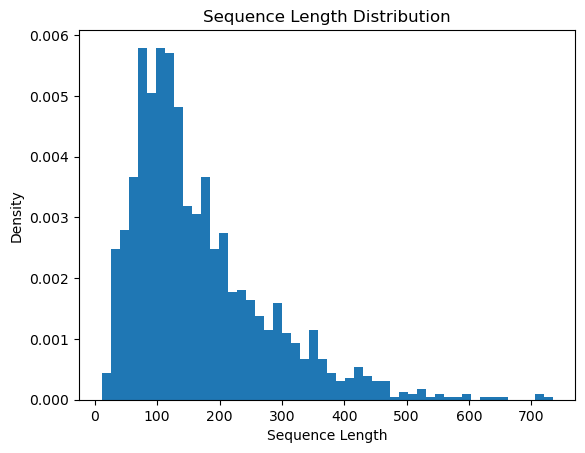

In [3]:
length=[]
for i in range(len(sequence)):
    length.append(len(sequence[i]))

plt.figure()
plt.hist(length, bins=50, density=True)
plt.xlabel("Sequence Length")
plt.ylabel("Density")
plt.title("Sequence Length Distribution")
plt.show()

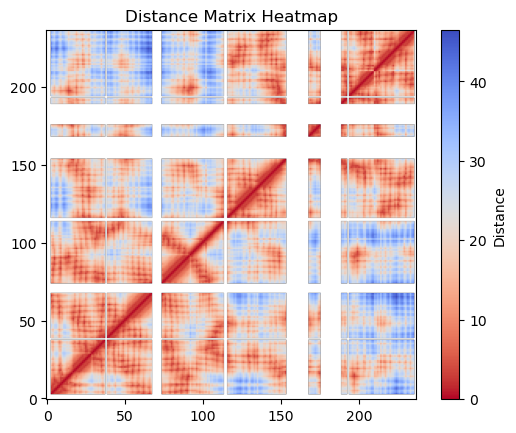

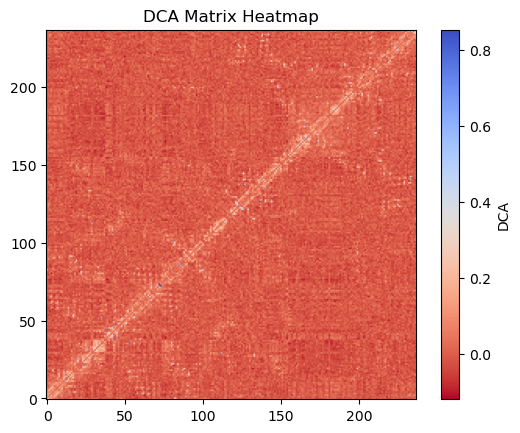

In [81]:
num=50
seq=sequence[num]
dist=distance_map[num]
dca_map=dca[num]

plt.figure()
plt.imshow(dist,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="Distance")
plt.title("Distance Matrix Heatmap")
plt.show()


plt.figure()
plt.imshow(dca_map,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="DCA")
plt.title("DCA Matrix Heatmap")
plt.show()

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ...  True  True False]
 [False False False ...  True  True False]
 [False False False ... False False False]]


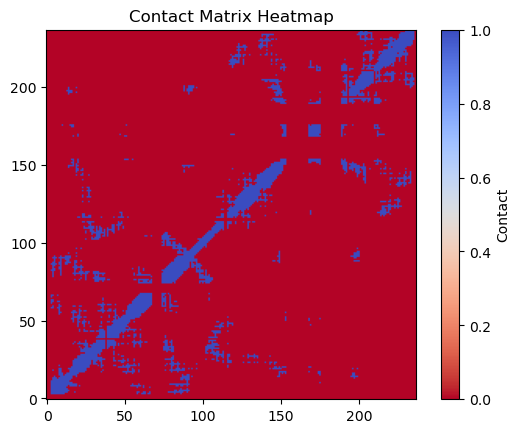

In [86]:
def contact_from_distance(distance_map, threshold=8.0):
    contact_map = (distance_map < threshold).astype(int)
    return contact_map  

contact_map = contact_from_distance(dist, threshold=8.0)
isfinite = np.isfinite(dist)

print(isfinite)
plt.figure()
plt.imshow(contact_map,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="Contact")
plt.title("Contact Matrix Heatmap")
plt.show()

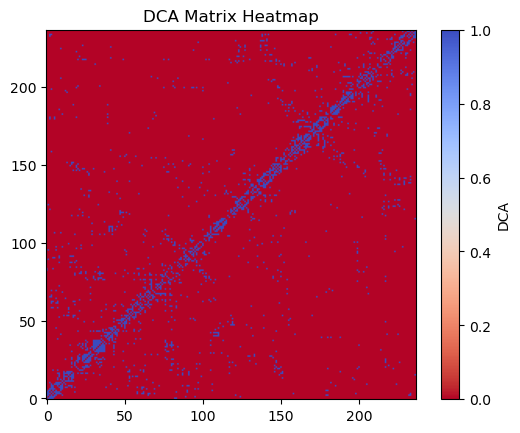

In [6]:
import numpy as np

def top_k_mask(matrix, k):
    n = matrix.shape[0]

    # Get upper triangle indices (excluding diagonal)
    triu_indices = np.triu_indices(n, k=1)

    # Extract corresponding values
    values = matrix[triu_indices]

    # Get indices of top-k values
    top_k_idx = np.argpartition(values, -k)[-k:]

    # Create empty mask
    mask = np.zeros_like(matrix, dtype=int)

    # Map back to matrix indices
    rows = triu_indices[0][top_k_idx]
    cols = triu_indices[1][top_k_idx]

    # Set both (i,j) and (j,i) = 1 (since symmetric)
    mask[rows, cols] = 1
    mask[cols, rows] = 1

    return mask

k = 5*len(seq)  
binary_map = top_k_mask(dca_map, k)
plt.figure()
plt.imshow(binary_map,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="DCA")
plt.title("DCA Matrix Heatmap")
plt.show()

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0.  0.  0.  ... 0.  0.  0. ]
 [0.  0.  0.  ... 0.  0.  0. ]
 [0.  0.  0.  ... 0.  0.  0. ]
 ...
 [0.  0.  0.  ... 0.  0.5 0. ]
 [0.  0.  0.  ... 0.5 0.  0. ]
 [0.  0.  0.  ... 0.  0.  0. ]]


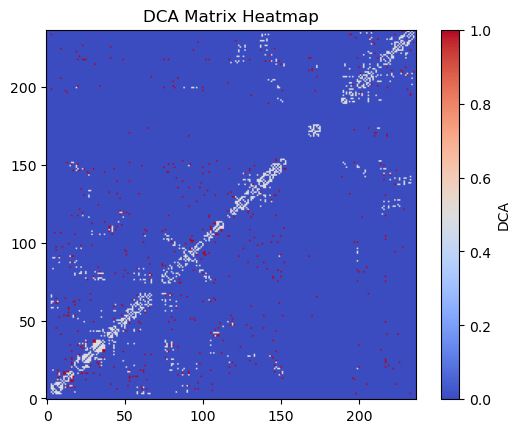

In [7]:
true_positives = (binary_map == 1) & (contact_map == 1)
false_positives = (binary_map == 1) & (contact_map== 0)

true_positives = true_positives.astype(float)
false_positives = false_positives.astype(float)
print(true_positives)

result= np.zeros_like(true_positives)
for i in range(len(true_positives)):
    for j in range(len(true_positives)):
        if true_positives[i][j] == 1 and isfinite[i][j]:
            result[i][j] = 0.5
        elif false_positives[i][j] == 1 and isfinite[i][j]:
            result[i][j] = 1.0
        else:
            result[i][j] = 0.0

print(result)
plt.figure()
plt.imshow(result,cmap='coolwarm', origin='lower')
#plt.imshow(false_positives,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="DCA")
plt.title("DCA Matrix Heatmap")
plt.show()

In [8]:
stats=np.zeros((1000,3))


for i in range(len(sequence)):
    seq=sequence[i]
    dist=distance_map[i]
    dca_map=dca[i]

    contact_map = contact_from_distance(dist, threshold=8.0)
    isfinite = np.isfinite(dist)

    k = 5*len(seq)  
    binary_map = top_k_mask(dca_map, k)

    n = binary_map.shape[0]

    for i in range(n):
        for j in range(i+1, n):  # upper triangle only

            d = abs(i - j)

            if isfinite[i][j]:
                stats[d, 2] += 1  # total pairs at distance d

            if binary_map[i, j]==1:

                if contact_map[i, j]==1 and isfinite[i][j]:
                    #true positives
                    stats[d, 0] += 1

                elif contact_map[i, j]==0 and isfinite[i][j]:
                    #false positives
                    stats[d, 1] += 1



    

In [77]:
print(stats)
tp = stats[:, 0]
fp = stats[:, 1]
total_seen = stats[:, 2]
distances = np.arange(len(stats))
total_percentage = np.where(total_seen > 0, (tp + fp)/ total_seen , 0)
precision = np.where((tp + fp) > 0, tp / (tp + fp), 0)
print(precision)


[[     0.      0.      0.]
 [124067.    265. 235982.]
 [ 92239.    549. 232859.]
 ...
 [     0.      0.      0.]
 [     0.      0.      0.]
 [     0.      0.      0.]]
[0.         0.99786861 0.99408329 0.97647786 0.83860011 0.72296892
 0.64751428 0.63175742 0.45989727 0.45475271 0.43641618 0.43595264
 0.45533559 0.44328989 0.44385981 0.44646903 0.45632693 0.45917254
 0.44950314 0.45240041 0.46679357 0.46522556 0.47685426 0.48374526
 0.49014882 0.49847224 0.49978974 0.49147155 0.4958994  0.49244108
 0.48973945 0.49199111 0.48256859 0.4832649  0.47731629 0.46741871
 0.4629156  0.45517624 0.45499929 0.45113221 0.4489523  0.44056808
 0.43686387 0.43793721 0.42788779 0.42343698 0.41675504 0.4145014
 0.40082645 0.41126919 0.40026051 0.41209867 0.41085587 0.40379902
 0.40177283 0.39791449 0.39257351 0.38081836 0.38207233 0.37431569
 0.37956714 0.37365269 0.37062257 0.36853659 0.35902586 0.3563278
 0.34926082 0.36906048 0.3541959  0.3595815  0.35249151 0.35336195
 0.33961708 0.34607154 0.33650

/tmp/ipykernel_2764811/3789995109.py:6: RuntimeWarning: invalid value encountered in divide
  total_percentage = np.where(total_seen > 0, (tp + fp)/ total_seen , 0)
/tmp/ipykernel_2764811/3789995109.py:7: RuntimeWarning: invalid value encountered in divide
  precision = np.where((tp + fp) > 0, tp / (tp + fp), 0)


ValueError: x and y must have same first dimension, but have shapes (236,) and (1000,)

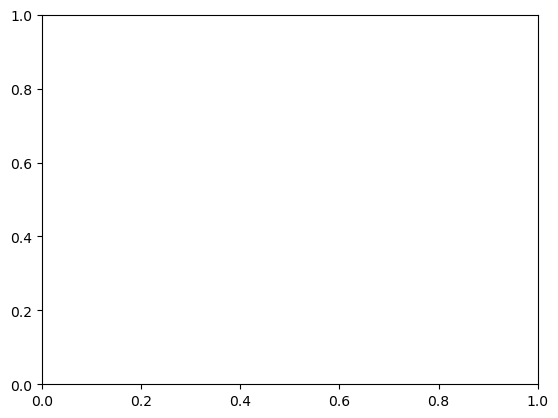

In [106]:
plt.plot(distances, total_percentage, label="Percentage of contacts")

In [61]:
L=700
total=0
for d in range(1, L):
    total += ((L-d)*total_percentage[d])
    print((L-d)*total_percentage[d])
print(total)
print(5*L)


368.2826147757032
278.13408113923015
249.7299106852099
224.5866019017391
107.73589871760277
80.77522194958733
79.96069939693204
63.510756148637014
49.84368890350637
46.15180679637122
44.522005462529734
39.92979080162352
36.70792496153502
36.459336992482626
34.64049042262666
33.40717583686033
33.350565858574114
32.81719443766772
32.764680731861944
31.834443151719185
32.430255118581506
32.746398838383584
33.41631781160308
32.897910472120074
32.92166848239429
33.191244382778684
33.13916740570713
32.30259768930753
31.97065802296513
31.021068307863118
30.77942679476283
30.230619923878507
29.287886403618998
28.69583172732779
27.80458232989668
27.586828624477103
26.930042219303633
26.370770620621474
25.911696656625473
25.635913391326437
24.83985313712826
24.265320125974277
23.87699611566681
23.696427081222208
23.548633314902517
22.420275805239815
22.722478801651885
22.348733233979136
21.588594982835364
21.864535149379385
20.92583685243749
20.290088289400817
20.333739873929623
20.2817016264214

In [67]:
import numpy as np

L = 100  # example
K = 5 * L

# distances you consider
distances = np.arange(1, L)

density = total_percentage[:L] 

# number of possible pairs at each distance
N_d = L-distances 

# weights
w = N_d * density[distances]
#print(w)

# normalize to probabilities
P = w / w.sum()

print(P)

[1.39257931e-01 1.04257081e-01 9.27876594e-02 8.27040046e-02
 3.93169609e-02 2.92097100e-02 2.86488372e-02 2.25428965e-02
 1.75248465e-02 1.60717374e-02 1.53541651e-02 1.36355283e-02
 1.24108936e-02 1.22029211e-02 1.14760673e-02 1.09532664e-02
 1.08203497e-02 1.05344443e-02 1.04045799e-02 9.99905676e-03
 1.00736854e-02 1.00579427e-02 1.01470862e-02 9.87451815e-03
 9.76607442e-03 9.72917600e-03 9.59688058e-03 9.24020004e-03
 9.03167092e-03 8.65288016e-03 8.47547803e-03 8.21599573e-03
 7.85448477e-03 7.59222771e-03 7.25585823e-03 7.09895418e-03
 6.83195122e-03 6.59382206e-03 6.38417713e-03 6.22209750e-03
 5.93740020e-03 5.71043019e-03 5.53056978e-03 5.40067145e-03
 5.27919615e-03 4.94239742e-03 4.92378518e-03 4.75871133e-03
 4.51537961e-03 4.49032316e-03 4.21808104e-03 4.01264621e-03
 3.94358805e-03 3.85576365e-03 3.75956870e-03 3.60293874e-03
 3.52065222e-03 3.38395014e-03 3.24118056e-03 3.12606311e-03
 2.98678869e-03 2.89107995e-03 2.83138986e-03 2.69967293e-03
 2.56337216e-03 2.467424

In [69]:
# multinomial draw → exact total K
contacts_per_d = np.random.multinomial(K, P)
print(contacts_per_d)

[63 56 46 51 24 13 15  6 10  3  8  9  8  5  5  4  5  8  5  7  4  3  5  4
  5  6  3  6  3  5  3  4  2  8  3 10  3  5  2  1  1  3  1  1  3  2  0  2
  3  1  0  4  0  4  3  4  0  2  3  1  2  0  1  2  1  2  0  4  0  0  0  1
  2  1  5  2  0  0  0  0  1  0  0  0  0  0  1  0  0  1  0  0  0  0  0  0
  0  0  0]


In [ ]:
import numpy as np

def remap_contact_map_by_distance(
    contact_map,
    target_contacts_by_d,
    good_fraction_by_d,
    seed=None,
):
    rng = np.random.default_rng(seed)
    contact_map = np.asarray(contact_map)
    n = contact_map.shape[0]

    new_map = np.zeros((n, n), dtype=np.int8)
    selected_good = {}
    selected_bad = {}

    for d in range(1, n):
        total_target = int(target_contacts_by_d[d])
        if total_target <= 0:
            selected_good[d] = 0
            selected_bad[d] = 0
            continue

        good_target = int(round(total_target * good_fraction_by_d[d]))
        good_target = max(0, min(good_target, total_target))
        bad_target = total_target - good_target

        i = np.arange(0, n - d)
        j = i + d

        # pairs at this distance
        real_mask = contact_map[i, j] > 0
        real_i, real_j = i[real_mask], j[real_mask]
        non_i, non_j = i[~real_mask], j[~real_mask]

        if good_target > len(real_i):
            good_target = len(real_i)
            bad_target = total_target - good_target
            print(f"Distance {d}: need {good_target} good contacts, "
                f"but only {len(real_i)} real contacts exist. Using all available.")
        if bad_target > len(non_i):
            raise ValueError(
                f"Distance {d}: need {bad_target} bad contacts, "
                f"but only {len(non_i)} non-contacts exist."
            )

        good_idx = rng.choice(len(real_i), size=good_target, replace=False)
        bad_idx = rng.choice(len(non_i), size=bad_target, replace=False)

        gi, gj = real_i[good_idx], real_j[good_idx]
        bi, bj = non_i[bad_idx], non_j[bad_idx]

        new_map[gi, gj] = 1
        new_map[gj, gi] = 1
        new_map[bi, bj] = 1
        new_map[bj, bi] = 1

        selected_good[d] = good_target
        selected_bad[d] = bad_target

    return new_map, selected_good, selected_bad

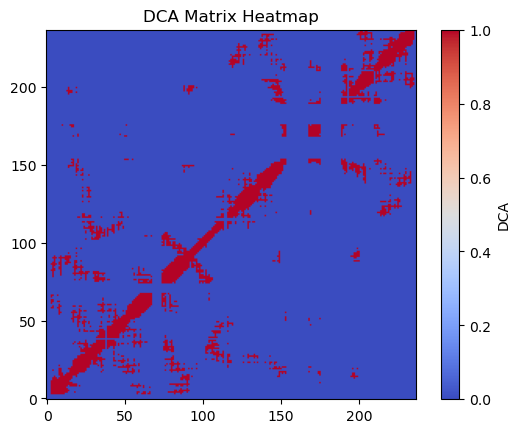

[  0 117  92  80  64  26  21  31  23  19  13   9  17  13  12  13   6  13
   7  10   9   9  11  12  13  11   2   9   7  12  13  15  11   8   6  10
   9   5   7   8   5   8   3   7   4   3   6   6   5   6   6   6   3   5
   6   7   3   7   2   5   7   2   5   5   5   6   1   3   3   2   4   6
  10   4   2   5   5   5   2   5   3   3   2   2   1   5   0   3   2   4
   2   3   2   7   2   5   5   2   0   3   5   3   3   3   1   0   4   2
   3   2   8   3   2   0   3   2   4   2   1   4   1   3   2   4   3   2
   3   1   2   2   0   4   2   1   3   1   1   3   1   3   3   2   4   1
   1   0   3   1   1   0   3   1   0   0   0   0   1   1   2   1   0   1
   0   0   1   1   2   1   3   5   3   1   0   1   0   1   1   1   0   2
   2   1   1   1   0   2   0   2   0   0   0   0   1   0   0   1   0   1
   1   1   0   0   0   0   0   0   0   0   1   0   1   1   0   0   0   1
   0   0   0   0   0   0   0   0   0   0   1   1   0   0   0   0   0   0
   0   0   0]


In [103]:
contact_map = contact_map

plt.figure()
plt.imshow(contact_map,cmap='coolwarm', origin='lower')
#plt.imshow(false_positives,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="DCA")
plt.title("DCA Matrix Heatmap")
plt.show()


L = len(contact_map)  # example
K = 5 * L

# distances you consider
distances = np.arange(1, L)

density = total_percentage[:L] 

# number of possible pairs at each distance
N_d = L-distances 

# weights
w = N_d * density[distances]
#print(w)

# normalize to probabilities
P = w / w.sum()
#number of contact needed at each distance
contacts_per_d = np.append(np.array([0]), np.random.multinomial(K, P))

print(contacts_per_d)

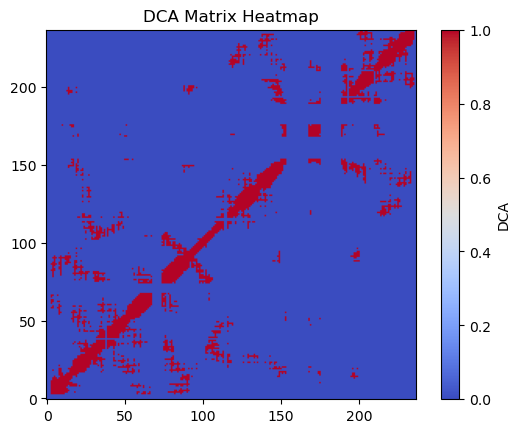

Distance 115: need 0 good contacts, but only 0 real contacts exist. Using all available.
Distance 125: need 0 good contacts, but only 0 real contacts exist. Using all available.
Distance 138: need 0 good contacts, but only 0 real contacts exist. Using all available.
Distance 140: need 0 good contacts, but only 0 real contacts exist. Using all available.
Distance 143: need 0 good contacts, but only 0 real contacts exist. Using all available.
Distance 146: need 0 good contacts, but only 0 real contacts exist. Using all available.
Distance 155: need 0 good contacts, but only 0 real contacts exist. Using all available.
Distance 186: need 0 good contacts, but only 0 real contacts exist. Using all available.
Distance 197: need 0 good contacts, but only 0 real contacts exist. Using all available.
Distance 214: need 0 good contacts, but only 0 real contacts exist. Using all available.


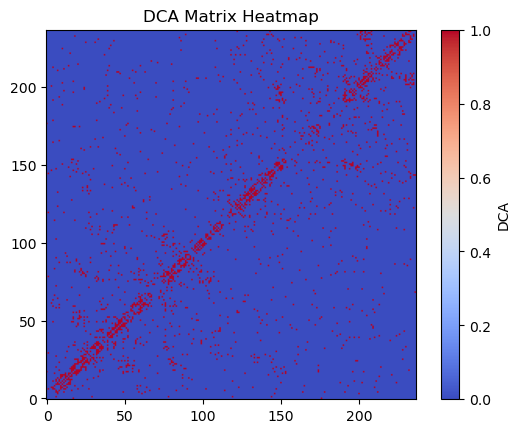

In [ ]:
contact_map = contact_map[]

plt.figure()
plt.imshow(contact_map,cmap='coolwarm', origin='lower')
#plt.imshow(false_positives,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="DCA")
plt.title("DCA Matrix Heatmap")
plt.show()


L = len(contact_map)  # example
K = 5 * L

# distances you consider
distances = np.arange(1, L)

density = total_percentage[:L] 

# number of possible pairs at each distance
N_d = L-distances 

# weights
w = N_d * density[distances]
#print(w)

# normalize to probabilities
P = w / w.sum()
#number of contact needed at each distance
contacts_per_d = np.append(np.array([0]), np.random.multinomial(K, P))


#percentage of good contacts needed at each distance
good_fraction_by_d = precision[:L]

new_map, good_counts, bad_counts = remap_contact_map_by_distance(contact_map, contacts_per_d, good_fraction_by_d,seed=1)

plt.figure()
plt.imshow(new_map,cmap='coolwarm', origin='lower')
#plt.imshow(false_positives,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="DCA")
plt.title("DCA Matrix Heatmap")
plt.show()

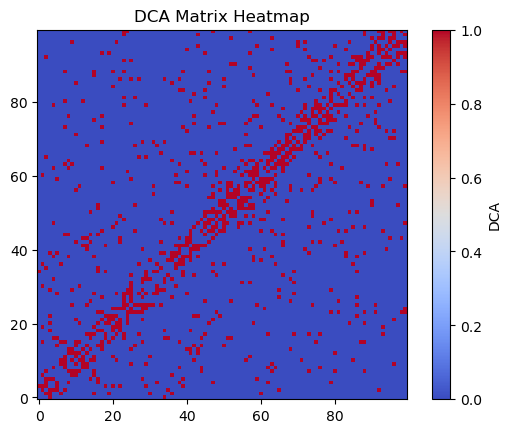

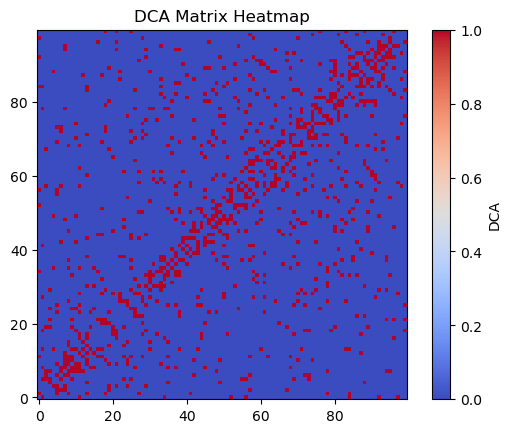

In [72]:
contact_map = np.zeros((L, L), dtype=int)

for idx, d in enumerate(distances):
    n_contacts = contacts_per_d[idx]
    
    if n_contacts == 0:
        continue
    
    # all possible pairs at distance d
    i = np.arange(L - d)
    j = i + d
    
    pairs = list(zip(i, j))
    
    # sample without replacement
    chosen = np.random.choice(len(pairs), size=min(n_contacts, len(pairs)), replace=False)
    
    for c in chosen:
        x, y = pairs[c]
        contact_map[x, y] = 1
        contact_map[y, x] = 1  # keep symmetry


plt.figure()
plt.imshow(contact_map,cmap='coolwarm', origin='lower')
#plt.imshow(false_positives,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="DCA")
plt.title("DCA Matrix Heatmap")
plt.show()


#alternativa

contact_map = np.zeros((L, L), dtype=int)
occupied = set()

while len(occupied) < K:
    d = np.random.choice(distances, p=P)
    
    i = np.random.randint(0, L - d)
    j = i + d
    
    if (i, j) in occupied:
        continue
    
    occupied.add((i, j))
    contact_map[i, j] = 1
    contact_map[j, i] = 1

plt.figure()
plt.imshow(contact_map,cmap='coolwarm', origin='lower')
#plt.imshow(false_positives,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="DCA")
plt.title("DCA Matrix Heatmap")
plt.show()

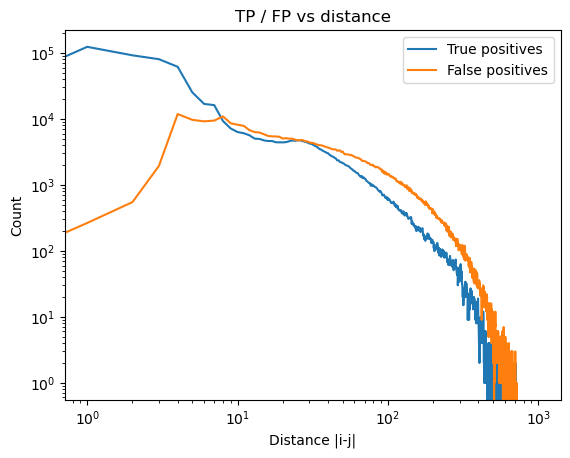

In [46]:
import matplotlib.pyplot as plt

plt.loglog(distances, tp, label="True positives")
plt.loglog(distances, fp, label="False positives")

plt.xlabel("Distance |i-j|")
plt.ylabel("Count")
plt.title("TP / FP vs distance")
plt.legend()
plt.show()

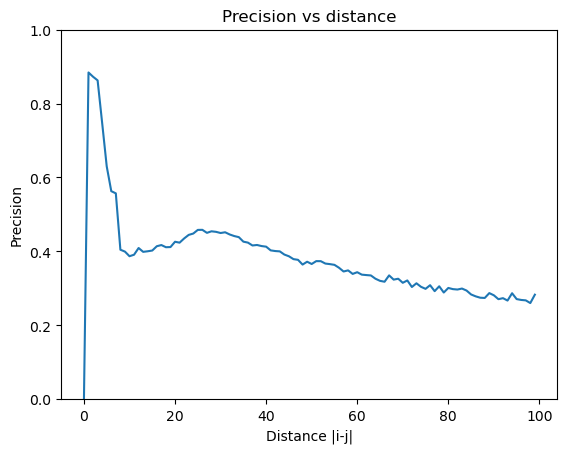

In [108]:
precision = np.divide(
    tp,
    tp + fp,
    out=np.zeros_like(tp, dtype=float),
    where=(tp + fp) != 0
)

plt.plot(distances[:100], precision[:100])
plt.xlabel("Distance |i-j|")
plt.ylabel("Precision")
plt.title("Precision vs distance")
plt.ylim(0, 1)
plt.show()

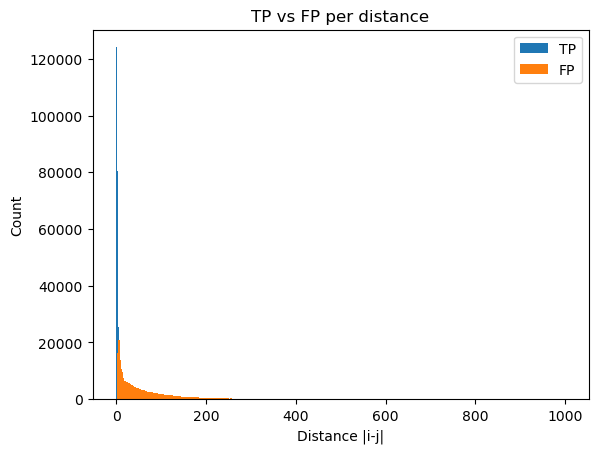

In [107]:
width = 3

plt.bar(distances - width/2, tp, width=width, label="TP")
plt.bar(distances + width/2, fp, width=width, label="FP")

plt.xlabel("Distance |i-j|")
plt.ylabel("Count")
plt.title("TP vs FP per distance")
plt.legend()
plt.show()

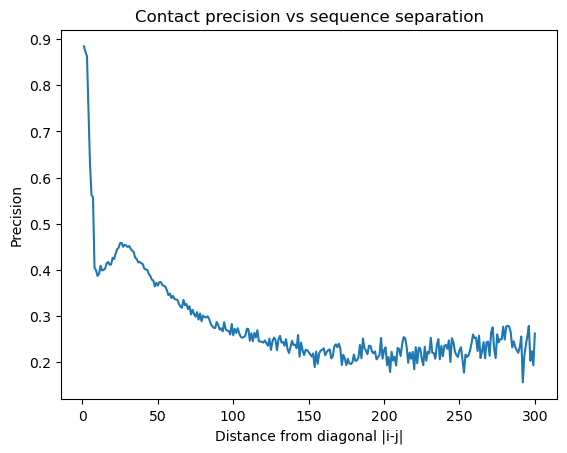

In [ ]:


plt.plot(distances[:300], values[:300])
plt.xlabel("Distance from diagonal |i-j|")
plt.ylabel("Precision")
plt.title("Contact precision vs sequence separation")
plt.show()


In [93]:
print(stats)   

defaultdict(<function <lambda> at 0x7314bd20b270>, {1: {'TP': 124067, 'FP': 16273}, 4: {'TP': 61726, 'FP': 20893}, 8: {'TP': 9312, 'FP': 13707}, 11: {'TP': 6075, 'FP': 9464}, 37: {'TP': 3280, 'FP': 4605}, 41: {'TP': 2854, 'FP': 4233}, 51: {'TP': 2105, 'FP': 3529}, 2: {'TP': 92239, 'FP': 13479}, 3: {'TP': 80577, 'FP': 12824}, 7: {'TP': 16209, 'FP': 12892}, 10: {'TP': 6342, 'FP': 10049}, 21: {'TP': 4455, 'FP': 6062}, 40: {'TP': 3021, 'FP': 4298}, 47: {'TP': 2361, 'FP': 3899}, 12: {'TP': 5658, 'FP': 8172}, 15: {'TP': 4729, 'FP': 7026}, 27: {'TP': 4639, 'FP': 5667}, 29: {'TP': 4430, 'FP': 5352}, 13: {'TP': 5034, 'FP': 7591}, 23: {'TP': 4717, 'FP': 5892}, 32: {'TP': 4028, 'FP': 5008}, 9: {'TP': 7181, 'FP': 10799}, 14: {'TP': 4977, 'FP': 7456}, 31: {'TP': 4208, 'FP': 5108}, 33: {'TP': 3884, 'FP': 4914}, 18: {'TP': 4433, 'FP': 6346}, 22: {'TP': 4584, 'FP': 5954}, 24: {'TP': 4677, 'FP': 5757}, 25: {'TP': 4731, 'FP': 5596}, 5: {'TP': 25335, 'FP': 14875}, 6: {'TP': 16893, 'FP': 13116}, 26: {'TP'